In [1]:
# Import packages
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from skimage import exposure
import torch

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [ ]:
#setting the input path
image_path = "../data/example_tiles/tile_243.jpg"

In [3]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [4]:
# Building the sam2 model
sam2_checkpoint = "../../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device,apply_postprocessing=False)

# Setting parameters for the AutomaticMaskGenerator 
# Mask generator with 32x32 input points
automatic_mask_generator32 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=32,
    points_per_batch=128,
    pred_iou_thresh=0.3,
    stability_score_thresh=0.5,
    box_nms_thresh=0.5,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=50
)

# Mask generator with 64x64 input points
automatic_mask_generator64 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=32,
    points_per_batch=128,
    pred_iou_thresh=0.3,
    stability_score_thresh=0.5,
    box_nms_thresh=0.5,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=50
)

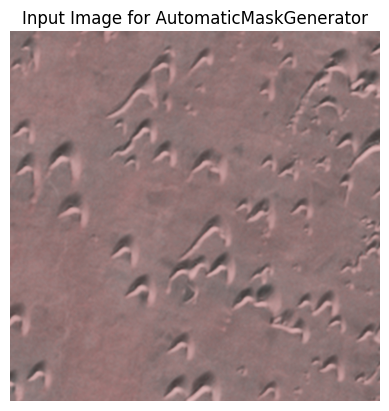

In [22]:
# reading the image and show image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image for AutomaticMaskGenerator")
plt.show()

In [23]:
# Compute Masks
masks32 = automatic_mask_generator32.generate(img)
masks64 = automatic_mask_generator64.generate(img)

# Filtering Masks for too big ones
filtered_masks32 = [
    m for m in masks32
    if m["area"] < 5000
]

filtered_masks64 = [
    m for m in masks64
    if m["area"] < 5000
]

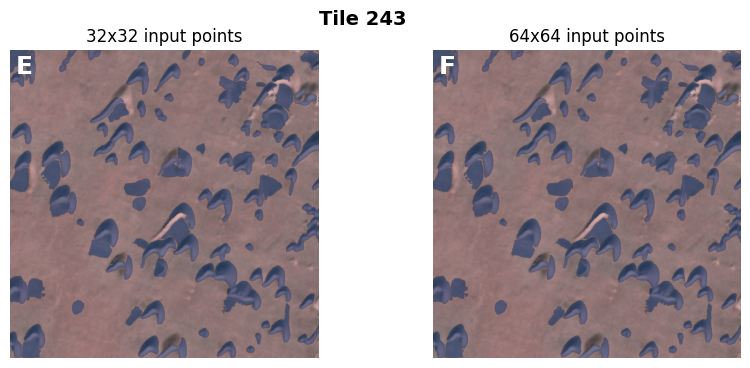

In [ ]:
# Plot Masks
# Create one mask output for all masks
H, W = masks32[0]["segmentation"].shape
full_mask32 = np.zeros((H, W), dtype=bool)

# Iterate over masks and add together
for m in filtered_masks32:
    full_mask32[m["segmentation"]] = 1

# Repeat for 64x64 masks
H, W = masks64[0]["segmentation"].shape
full_mask64 = np.zeros((H, W), dtype=bool)

for m in filtered_masks64:
    full_mask64[m["segmentation"]] = 1

# Masking out 0 values for visualization
masked32 = np.ma.masked_where(full_mask32 == 0, full_mask32)
masked64 = np.ma.masked_where(full_mask64 == 0, full_mask64)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.imshow(masked32, cmap= "Blues_r", alpha=0.5)
plt.title("32x32 input points", fontsize=12)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(masked64, cmap= "Blues_r", alpha=0.5)
plt.title("64x64 input points", fontsize=12)
plt.axis('off')

plt.show()